# ***Task 6: K-Nearest Neighbors (KNN) Classification***

In [3]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Saving Iris.csv to Iris (2).csv


In [4]:
df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['Species'].value_counts())

(150, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


**Choose a Classification Dataset and Normalize Features**

In [6]:
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Use KNeighborsClassifier from Scikit-Learn**

In [9]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

**Evaluate Model Using Accuracy and Confusion Matrix**

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



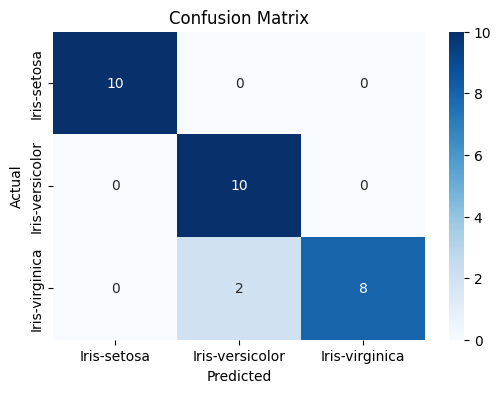

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Experiment with Different Values of K**

In [12]:
k_values = range(1, 21)

accuracies = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    accuracies.append(acc)

for k, acc in zip(k_values, accuracies):
    print(f"K={k}: Accuracy={acc:.4f}")

K=1: Accuracy=0.9667
K=2: Accuracy=0.9333
K=3: Accuracy=0.9333
K=4: Accuracy=0.9333
K=5: Accuracy=0.9333
K=6: Accuracy=0.9333
K=7: Accuracy=0.9667
K=8: Accuracy=0.9333
K=9: Accuracy=0.9667
K=10: Accuracy=0.9667
K=11: Accuracy=0.9667
K=12: Accuracy=0.9667
K=13: Accuracy=0.9667
K=14: Accuracy=0.9333
K=15: Accuracy=0.9333
K=16: Accuracy=0.9333
K=17: Accuracy=0.9667
K=18: Accuracy=0.9667
K=19: Accuracy=0.9667
K=20: Accuracy=0.9333


K vs Accuracy Plot

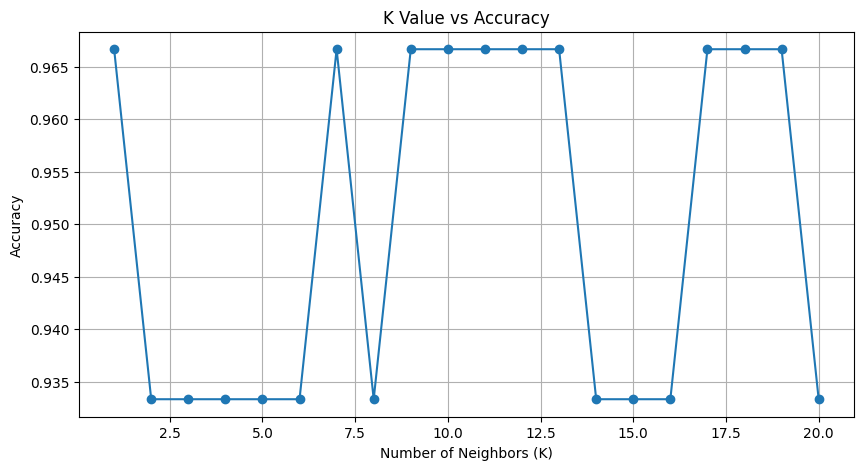

In [13]:
plt.figure(figsize=(10,5))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.title("K Value vs Accuracy")

plt.grid(True)

plt.show()

In [14]:
best_k = k_values[np.argmax(accuracies)]

best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 1
Best Accuracy: 0.9666666666666667


In [15]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train, y_train)

final_pred = final_knn.predict(X_test)

print("Final Accuracy:",
      accuracy_score(y_test, final_pred))

Final Accuracy: 0.9666666666666667


**Visualize Decision Boundaries**

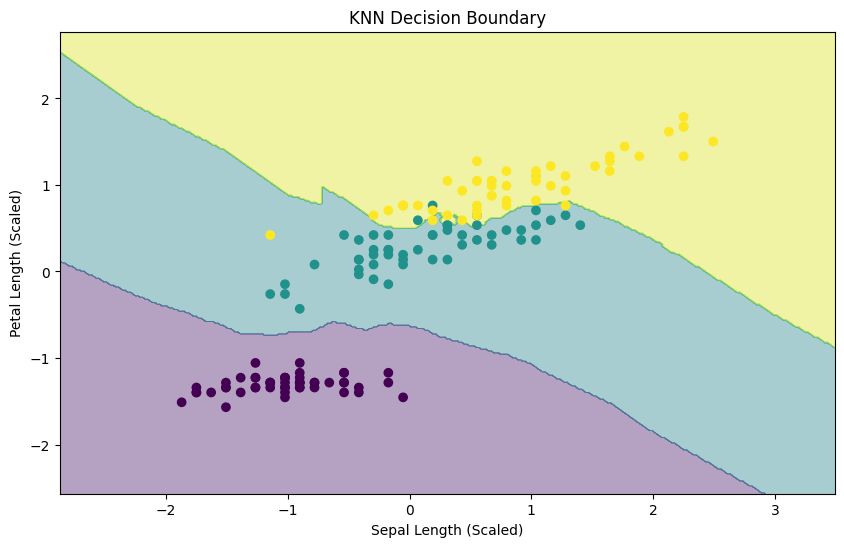

In [16]:
from matplotlib.colors import ListedColormap

X_vis = df[['SepalLengthCm', 'PetalLengthCm']]

y_vis = df['Species']

X_vis_scaled = StandardScaler().fit_transform(X_vis)

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis_scaled,
    y_vis,
    test_size=0.2,
    random_state=42
)

knn_vis = KNeighborsClassifier(n_neighbors=5)

knn_vis.fit(X_train_vis, y_train_vis)

x_min, x_max = X_vis_scaled[:,0].min()-1, X_vis_scaled[:,0].max()+1
y_min, y_max = X_vis_scaled[:,1].min()-1, X_vis_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])

species_map = {
    'Iris-setosa':0,
    'Iris-versicolor':1,
    'Iris-virginica':2,
    'setosa':0,
    'versicolor':1,
    'virginica':2
}

Z = np.array([species_map[label] for label in Z])

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))

plt.contourf(xx, yy, Z, alpha=0.4)

scatter = plt.scatter(
    X_vis_scaled[:,0],
    X_vis_scaled[:,1],
    c=[species_map[label] for label in y_vis]
)

plt.xlabel("Sepal Length (Scaled)")
plt.ylabel("Petal Length (Scaled)")

plt.title("KNN Decision Boundary")

plt.show()